In [1]:
!pip install -U datasets huggingface_hub fsspec

In [2]:
import datasets, huggingface_hub
print(datasets.__version__)
print(huggingface_hub.__version__)

5.0.0
1.18.0


In [3]:
from datasets import load_dataset

raw = load_dataset("fancyzhx/yelp_polarity")
print(raw)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})


In [4]:
from sklearn.model_selection import train_test_split

N_TRAIN = 200_000
N_TEST = 20_000 # VAL + TEST

splits = {
    split: raw[split].shuffle(seed=42).select(range(n))
    for split, n in {
        "train": N_TRAIN,
        "test": N_TEST,
    }.items()
}

train_texts, train_labels = splits["train"]["text"], splits["train"]["label"]
test_texts, test_labels = splits["test"]["text"], splits["test"]["label"]

val_texts, test_texts, val_labels, test_labels = (
    train_test_split(
        test_texts, test_labels, test_size=0.5, random_state=42
        )
    )

def print_distributions():
  for name, labels in {
      "Train": train_labels,
      "Validation": val_labels,
      "Test": test_labels
  }.items():
    print(f"\n {name} distribution:")
    print(f" Positive reviews: {sum(labels)/len(labels):.2%}.")

print_distributions()


 Train distribution:
 Positive reviews: 49.93%.

 Validation distribution:
 Positive reviews: 49.62%.

 Test distribution:
 Positive reviews: 50.27%.


In [5]:
import numpy as np

def pair_every_sentence_with_random(texts, labels, seed=1):
  rng = np.random.default_rng(seed)
  texts = np.array(texts, dtype=object)
  labels = np.array(labels)

  N = len(texts)
  random_indices = rng.integers(0, N, size=N)
  random_texts = texts[random_indices]

  separator = " SEPARATORTOKEN "

  augmented_texts = np.char.add(
      np.char.add(random_texts, separator),
      texts
  )

  full_texts = np.concatenate([texts, augmented_texts])
  full_labels = np.concatenate([labels, labels])

  return full_texts.tolist(), full_labels.tolist()

In [6]:
train_texts, train_labels = pair_every_sentence_with_random(train_texts, train_labels)
val_texts, val_labels = pair_every_sentence_with_random(val_texts, val_labels)
test_texts, test_labels = pair_every_sentence_with_random(test_texts, test_labels)

In [7]:
import re
MAX_LEN = 256

def tokenize(text):
  text = text.lower()
  text = re.sub(r'<[^>]+>', ' ', text)
  text = re.sub(r'[^a-z\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text.split()

def build_vocab(token_lists, min_freq=2):
  seen_words = {}
  for t_list in token_lists:
    for t in t_list:
      seen_words[t] = seen_words.get(t, 0) + 1

  vocab = {
      t: idx + 2
      for idx, (t, ct) in enumerate(seen_words.items())
      if ct >= min_freq
  }

  vocab.update({'<PAD>': 0, '<UNK>': 1})
  return vocab

def tokens_to_ids(tokens, vocab):
  return [vocab.get(t, 1) for t in tokens]

def pad(seq, max_len=MAX_LEN, pad_value=0):
  seq = seq[:max_len]
  return seq + [pad_value] * (max_len - len(seq))

def process_texts(texts, vocab, max_len=128):
  return [pad(tokens_to_ids(tokenize(text), vocab), max_len) for text in texts]

In [8]:
train_tokens = [tokenize(t) for t in train_texts]
vocab = build_vocab(train_tokens)

train_ids = process_texts(train_texts, vocab, MAX_LEN)
val_ids   = process_texts(val_texts, vocab, MAX_LEN)
test_ids  = process_texts(test_texts, vocab, MAX_LEN)

In [9]:
import torch

BATCH_SIZE = 1 << 10

torch.manual_seed(1)
torch.cuda.manual_seed(1)
torch.cuda.manual_seed_all(1)

# Convert all to tensors
def to_loader(input_ids, labels, batch_size=1 << 10, shuffle=False):
  x_tensor = torch.tensor(input_ids, dtype=torch.long)
  y_tensor = torch.tensor(labels, dtype=torch.long)
  return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(train_ids, train_labels, BATCH_SIZE, shuffle=True)
val_loader = to_loader(val_ids, val_labels, BATCH_SIZE)
test_loader = to_loader(test_ids, test_labels, BATCH_SIZE)


In [10]:
from time import time

if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

print(f"Working on {device}")

def train_model(net, train_loader, val_loader, epochs=1000, lr=.001, log_every=1):
  print(f"Working on {device}")
  net = net.to(device)
  optimizer = torch.optim.Adam(net.parameters(), lr=lr)
  criterion = torch.nn.BCEWithLogitsLoss()

  train_loss_history = []
  val_loss_history = []
  train_acc_history = []
  val_acc_history = []

  start_time = time()
  for epoch in range(epochs):
    net.train()

    train_loss_sum = .0
    train_correct = 0

    for batch_inputs, batch_labels in train_loader:
      batch_inputs = batch_inputs.to(device)
      batch_labels = batch_labels.to(device).float()

      optimizer.zero_grad()
      logits = net(batch_inputs)
      loss = criterion(logits, batch_labels)
      loss.backward()
      optimizer.step()

      train_loss_sum += loss.item() * batch_inputs.size(0)
      preds = (torch.sigmoid(logits) > .5).float()
      train_correct += (preds == batch_labels).sum().item()

    train_total = (len(train_loader) - 1) * train_loader.batch_size + batch_inputs.size(0)
    avg_train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_acc)

    # Validation

    net.eval()
    val_loss_sum = .0
    val_correct = 0

    with torch.no_grad():
      for batch_inputs, batch_labels in val_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device).float()

        logits = net(batch_inputs)
        loss = criterion(logits, batch_labels)

        val_loss_sum += loss.item() * batch_inputs.size(0)
        preds = (torch.sigmoid(logits) > .5).float()
        val_correct += (preds == batch_labels).sum().item()

    val_total = (len(val_loader) - 1) * val_loader.batch_size + batch_inputs.size(0)
    avg_val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    val_loss_history.append(avg_val_loss)
    val_acc_history.append(val_acc)

    if epoch % log_every == 0:
      print(f"Epoch {epoch:03d} | "
            f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

  end_time = time()
  print(f"Elapsed time: {end_time - start_time:.2f} seconds")

  return train_loss_history, val_loss_history, train_acc_history, val_acc_history

Working on cuda


In [11]:
import matplotlib.pyplot as plt

def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
  fig, axs = plt.subplots(1, 2, figsize=(14, 5))

  axs[0].plot(train_loss, label="Train Loss", color="blue")
  axs[0].plot(val_loss, label="Val Loss", color="orange")
  axs[0].set_title("Loss per Epoch")
  axs[0].set_xlabel("Epoch")
  axs[0].set_ylabel("Average Loss")
  axs[0].grid(True)
  axs[0].legend()

  axs[1].plot(train_acc, label="Train Accuracy", color='green')
  axs[1].plot(val_acc, label="Val Accuracy", color='red')
  axs[1].set_title("Accuracy per Epoch")
  axs[1].set_xlabel("Epoch")
  axs[1].set_ylabel("Accuracy")
  axs[1].grid(True)
  axs[1].legend()

  plt.tight_layout()
  plt.show()

## Global Query - Fixed viewpoint

In [12]:
pos_cnt = 16
positional_encoding_B = 1000

def sinusoid_positions(max_len=MAX_LEN, dim=pos_cnt):
  pos = torch.arange(max_len, device=device).float().unsqueeze(1)
  i = torch.arange(dim, device=device).float().unsqueeze(0)
  angle = pos / (positional_encoding_B ** (2 * (i//2) / dim))
  S = torch.zeros(max_len, dim, device=device)
  S[:, 0::2] = torch.sin(angle[:, 0::2])
  S[:, 1::2] = torch.cos(angle[:, 1::2])                              # size: words, features

  return S

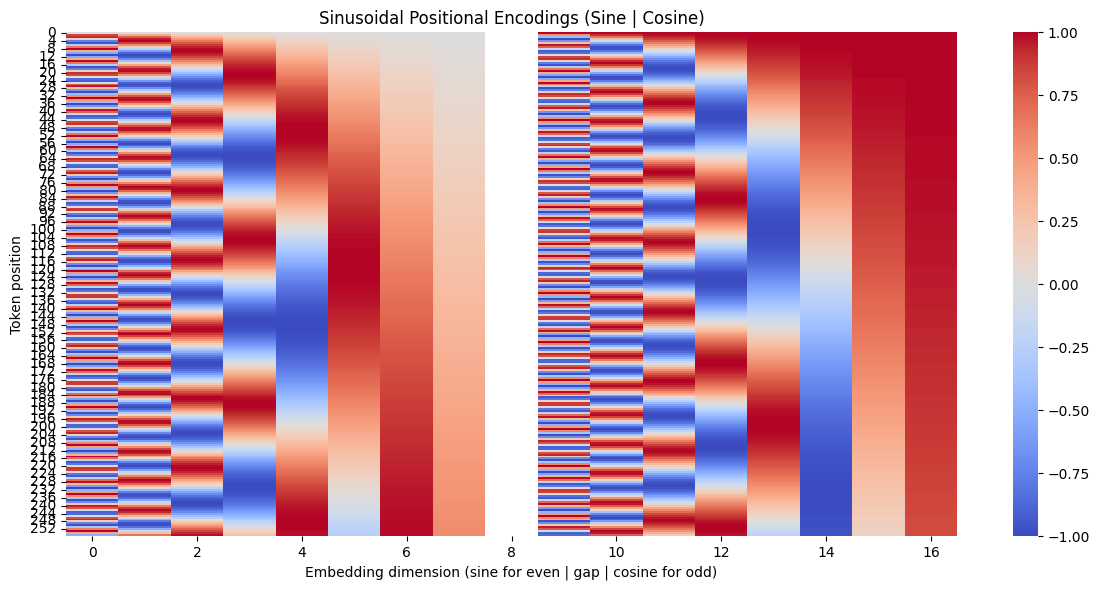

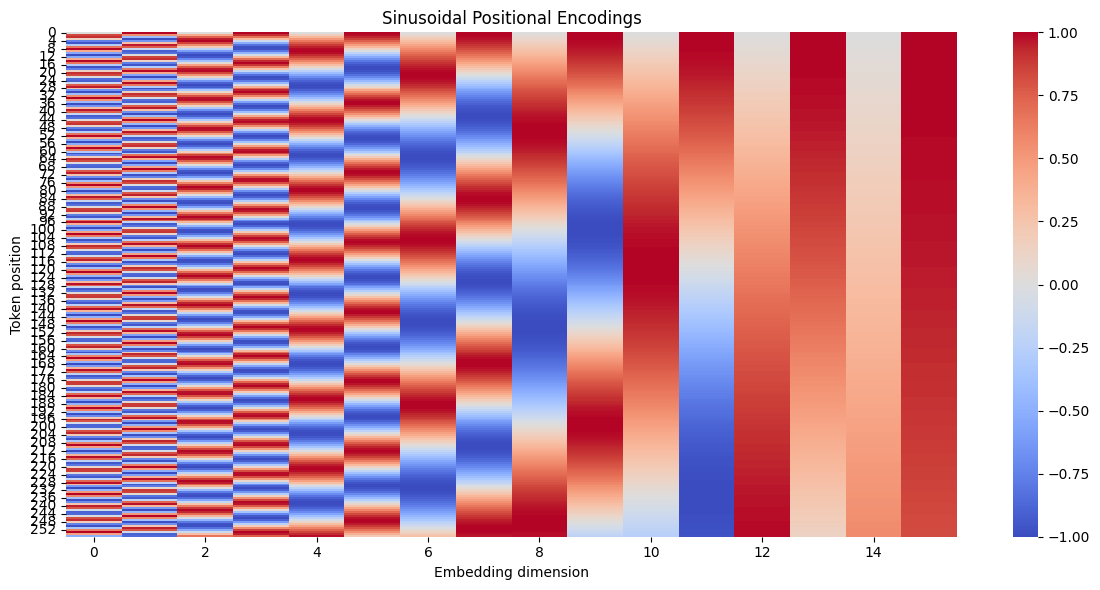

In [13]:
import seaborn as sns
S = sinusoid_positions()

sine = S[:, ::2]
cosine = S[:, 1::2]
gap = torch.full((S.size(0), 1), float("nan")).to(device)
S_sep = torch.cat([sine, gap, cosine], dim=1)

plt.figure(figsize=(12, 6))
sns.heatmap(S_sep.cpu().numpy(), cmap="coolwarm", cbar=True, xticklabels=2, yticklabels=4)
plt.title("Sinusoidal Positional Encodings (Sine | Cosine)")
plt.xlabel("Embedding dimension (sine for even | gap | cosine for odd)")
plt.ylabel("Token position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(S.cpu().numpy(), cmap="coolwarm", cbar=True, xticklabels=2, yticklabels=4)
plt.title("Sinusoidal Positional Encodings")
plt.xlabel("Embedding dimension")
plt.ylabel("Token position")
plt.tight_layout()
plt.show()

Working on cuda
Epoch 000 | Train Loss: 0.6570, Acc: 0.6055 | Val Loss: 0.5828, Acc: 0.6996
Epoch 001 | Train Loss: 0.5135, Acc: 0.7521 | Val Loss: 0.4593, Acc: 0.7864
Epoch 002 | Train Loss: 0.4246, Acc: 0.8100 | Val Loss: 0.3995, Acc: 0.8267
Epoch 003 | Train Loss: 0.3806, Acc: 0.8362 | Val Loss: 0.3762, Acc: 0.8397
Epoch 004 | Train Loss: 0.3597, Acc: 0.8483 | Val Loss: 0.3672, Acc: 0.8435
Epoch 005 | Train Loss: 0.3460, Acc: 0.8554 | Val Loss: 0.3621, Acc: 0.8465
Epoch 006 | Train Loss: 0.3349, Acc: 0.8614 | Val Loss: 0.3605, Acc: 0.8479
Epoch 007 | Train Loss: 0.3253, Acc: 0.8660 | Val Loss: 0.3594, Acc: 0.8475
Epoch 008 | Train Loss: 0.3166, Acc: 0.8700 | Val Loss: 0.3617, Acc: 0.8462
Epoch 009 | Train Loss: 0.3084, Acc: 0.8741 | Val Loss: 0.3638, Acc: 0.8452
Epoch 010 | Train Loss: 0.3002, Acc: 0.8776 | Val Loss: 0.3690, Acc: 0.8432
Epoch 011 | Train Loss: 0.2923, Acc: 0.8812 | Val Loss: 0.3739, Acc: 0.8407
Epoch 012 | Train Loss: 0.2842, Acc: 0.8847 | Val Loss: 0.3801, Acc: 0.8

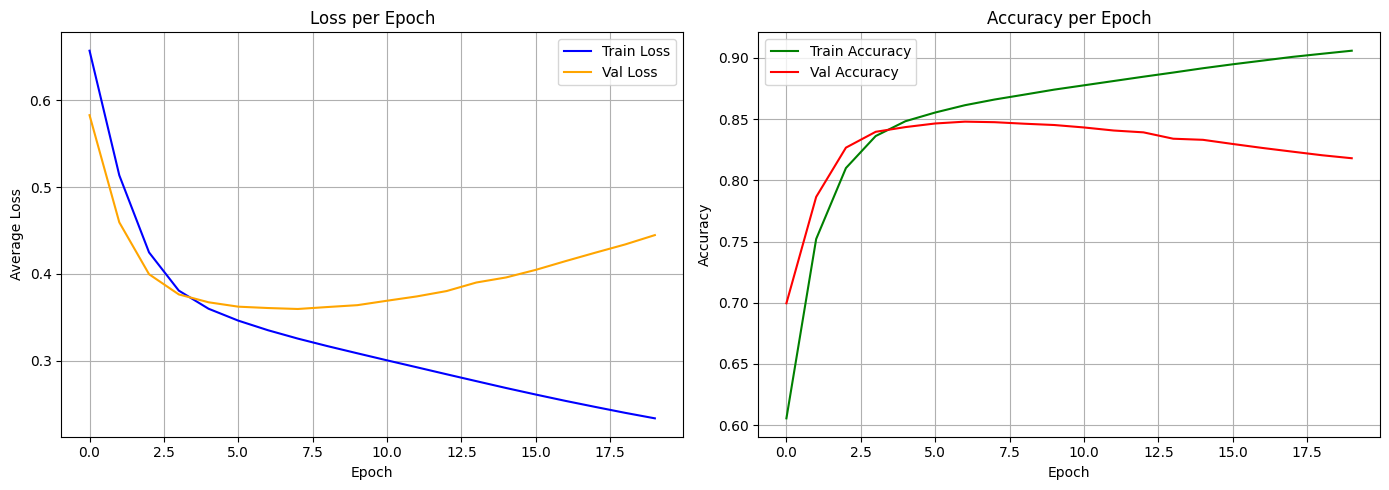

In [14]:
embed_cnt = 16
feature_cnt = 16
vocab_len = max(vocab.values()) + 1

class Attention(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.energy = torch.nn.Linear(feature_cnt, 1)

  def forward(self, features):                                      # size: batch, words, features
    energies = self.energy(features)                                # size: batch, words, 1
    energies = energies.transpose(-2, -1)                           # size: batch, 1, words
    weights = torch.nn.functional.softmax(energies, -1)             # size: batch, 1, words
    features = weights @ features                                   # size: batch, 1, features

    return features

class Net_Attention_And_PE(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_len, embed_cnt)
    self.attention = Attention()
    self.classifier = torch.nn.Linear(feature_cnt, 1)

  def forward(self, index):                                         # size: batch, words
    features = self.embedding(index) + S                            # size: batch, words, features
    features = self.attention(features)                             # size: batch, 1, features

    classifications = self.classifier(features)                     # size: batch, 1, 1
    logits = classifications.squeeze(-1).squeeze(-1)                # size: batch

    return logits

net_att_pe = Net_Attention_And_PE()

train_loss, val_loss, train_acc, val_acc = train_model(net_att_pe, train_loader, val_loader, epochs = 20)
plot_training_curves(train_loss, val_loss, train_acc, val_acc)

## Local Query - Self attention

### Set up

Let $F \in \mathrm{Mat}_{n \times d}(\mathbb{R})$ be the input feature matrix, $Q, K \in \mathrm{Mat}_{d \times k}(\mathbb{R})$ be the learnable projection matrices, and $V \in \mathrm{Mat}_{d \times d_v}(\mathbb{R})$ be the learnable value weight matrix.

We compute the energy matrix $E \in \mathrm{Mat}_{n \times n}(\mathbb{R})$ as

\begin{equation}
  E = \frac{(FQ)(FK)^T}{\sqrt{k}} = F \left( \frac{QK^T}{\sqrt{k}} \right) F^T.
\end{equation}

Then, we apply the softmax function row-wise on $E$ to obtain the attention weights matrix $A \in \mathrm{Mat}_{n \times n}(\mathbb{R})$, which represents a discrete probability distribution over the sequence space. Finally, we multiply this attention matrix by the projected value matrix to get the final output
\begin{equation}
  A \times (FV) \in \mathrm{Mat}_{n \times d_v}(\mathbb{R}).
\end{equation}

Working on cuda
Epoch 000 | Train Loss: 0.6360, Acc: 0.6301 | Val Loss: 0.5356, Acc: 0.7383
Epoch 001 | Train Loss: 0.4744, Acc: 0.7783 | Val Loss: 0.4291, Acc: 0.8065
Epoch 002 | Train Loss: 0.4041, Acc: 0.8210 | Val Loss: 0.3894, Acc: 0.8294
Epoch 003 | Train Loss: 0.3721, Acc: 0.8389 | Val Loss: 0.3714, Acc: 0.8385
Epoch 004 | Train Loss: 0.3536, Acc: 0.8490 | Val Loss: 0.3611, Acc: 0.8448
Epoch 005 | Train Loss: 0.3397, Acc: 0.8566 | Val Loss: 0.3554, Acc: 0.8478
Epoch 006 | Train Loss: 0.3278, Acc: 0.8625 | Val Loss: 0.3517, Acc: 0.8500
Epoch 007 | Train Loss: 0.3171, Acc: 0.8679 | Val Loss: 0.3496, Acc: 0.8517
Epoch 008 | Train Loss: 0.3071, Acc: 0.8726 | Val Loss: 0.3481, Acc: 0.8505
Epoch 009 | Train Loss: 0.2974, Acc: 0.8772 | Val Loss: 0.3496, Acc: 0.8509
Epoch 010 | Train Loss: 0.2882, Acc: 0.8811 | Val Loss: 0.3522, Acc: 0.8509
Epoch 011 | Train Loss: 0.2793, Acc: 0.8852 | Val Loss: 0.3552, Acc: 0.8498
Epoch 012 | Train Loss: 0.2705, Acc: 0.8892 | Val Loss: 0.3603, Acc: 0.8

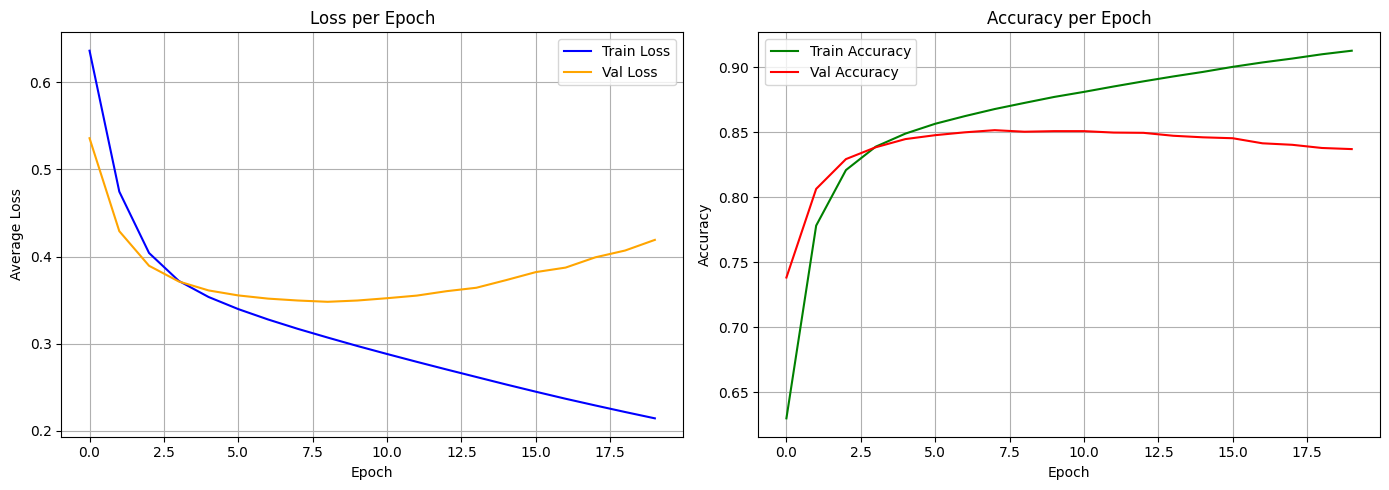

In [15]:
k = 8
d_v = feature_cnt

class SelfAttention(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.Q = torch.nn.Linear(feature_cnt, k)
    self.K = torch.nn.Linear(feature_cnt, k)
    self.V = torch.nn.Linear(feature_cnt, d_v)
    self.attention = None

  def forward(self, features):                                            # size: batch, words, d
    queries = self.Q(features)                                            # size: batch, words, k
    keys = self.K(features)                                               # size: batch, words, k
    keys = keys.transpose(-2, -1)                                         # size: batch, k, words

    energies = (queries @ keys) / (k ** .5)                               # size: batch, words, words
    self.attention = torch.nn.functional.softmax(energies, dim=-1)        # size: batch, words, words

    values = self.V(features)                                             # size: batch, words, d_v
    output = self.attention @ values                                      # size: batch, words, d_v

    return output

class Net_SelfAttention(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_len, embed_cnt)
    self.attention = SelfAttention()
    self.classifier = torch.nn.Linear(d_v, 1)

  def forward(self, index):                                               # size: batch, words
    features = self.embedding(index) + S                                  # size: batch, words, d
    attended = self.attention(features)                                   # size: batch, words, d_v
    pooled = attended.mean(dim=-2)                                        # size: batch, d_v
    pooled = torch.nn.functional.sigmoid(pooled)                          # size: batch, d_v

    output = self.classifier(pooled)                                      # size: batch, 1
    logits = output.squeeze(-1)                                           # size: batch

    return logits

net_selfatt = Net_SelfAttention()
train_loss, val_loss, train_acc, val_acc = train_model(net_selfatt, train_loader, val_loader, epochs=20)
plot_training_curves(train_loss, val_loss, train_acc, val_acc)

In [16]:
combined_dataset = torch.utils.data.ConcatDataset([train_loader.dataset, val_loader.dataset])

final_loader = torch.utils.data.DataLoader(
    combined_dataset,
    batch_size=train_loader.batch_size,
    shuffle=True
)

In [18]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

print(f"Working on {device}")

net = Net_SelfAttention()
net = net.to(device)
lr =.001
epochs = 15

optimizer = torch.optim.Adam(net.parameters(), lr=lr)
criterion = torch.nn.BCEWithLogitsLoss()

start_time = time()
for epoch in range(epochs):
  net.train()

  for batch_inputs, batch_labels in final_loader:
    batch_inputs = batch_inputs.to(device)
    batch_labels = batch_labels.to(device).float()

    optimizer.zero_grad()
    logits = net(batch_inputs)
    loss = criterion(logits, batch_labels)
    loss.backward()
    optimizer.step()

end_time = time()
print(f"Elapsed time: {end_time - start_time:.2f} seconds")

Working on cuda
Elapsed time: 239.59 seconds


In [19]:
def evaluate(model, loader):
  model.eval()
  correct = 0

  with torch.no_grad():
    for x_batch, y_batch in loader:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)
      logits = model(x_batch)
      preds = (logits > 0).long()
      correct += (preds == y_batch).sum().item()

    total = (len(loader) - 1) * loader.batch_size + x_batch.size(0)
    return correct / total

test_accuracy = evaluate(net, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8451
